# Assignment 6: Data Sets
### DATA 620
### Miraj Patel

## Introduction
This assignment explores a famous 1941 study by Allison Davis, Burleigh Gardner, and Mary Gardner, which tracked the social lives of 18 women in the American South at 14 distinct social events over a period of time. Since this is a two-mode (bipartite) network, we aren't just looking at who knows whom, we are looking at how shared activities create a social structure.

## Dataset

Biadjacency matrix
<Compressed Sparse Row sparse array of dtype 'int64'
	with 89 stored elements and shape (18, 14)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 7)	1
  (0, 8)	1
  (1, 0)	1
  (1, 1)	1
  (1, 2)	1
  (1, 4)	1
  (1, 5)	1
  (1, 6)	1
  (1, 7)	1
  (2, 1)	1
  (2, 2)	1
  (2, 3)	1
  (2, 4)	1
  (2, 5)	1
  (2, 6)	1
  (2, 7)	1
  (2, 8)	1
  (3, 0)	1
  (3, 2)	1
  :	:
  (12, 7)	1
  (12, 8)	1
  (12, 9)	1
  (12, 11)	1
  (12, 12)	1
  (12, 13)	1
  (13, 5)	1
  (13, 6)	1
  (13, 8)	1
  (13, 9)	1
  (13, 10)	1
  (13, 11)	1
  (13, 12)	1
  (13, 13)	1
  (14, 6)	1
  (14, 7)	1
  (14, 9)	1
  (14, 10)	1
  (14, 11)	1
  (15, 7)	1
  (15, 8)	1
  (16, 8)	1
  (16, 10)	1
  (17, 8)	1
  (17, 10)	1

#Friends, Member
17 Evelyn Jefferson
15 Laura Mandeville
17 Theresa Anderson
15 Brenda Rogers
11 Charlotte McDowd
15 Frances Anderson
15 Eleanor Nye
16 Pearl Oglethorpe
17 Ruth DeSand
17 Verne Sanderson
16 Myra Liddel
16 Katherina Rogers
17 Sylvia Avondale
17 Nora Fayette
1

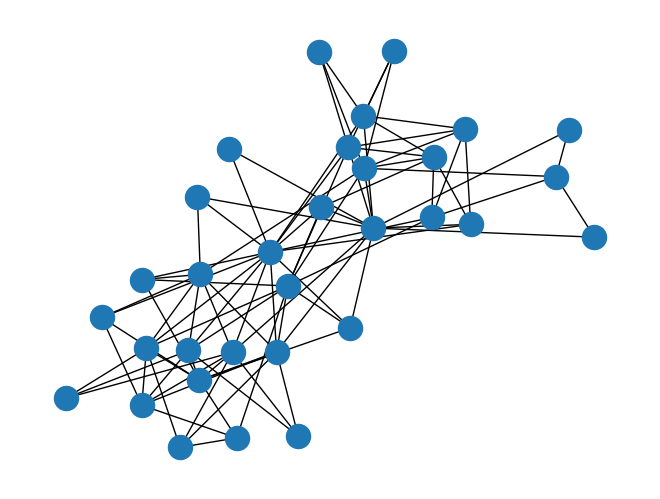

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite

G = nx.davis_southern_women_graph()
women = G.graph["top"]
clubs = G.graph["bottom"]

print("Biadjacency matrix")
print(bipartite.biadjacency_matrix(G, women, clubs))

# project bipartite graph onto women nodes
W = bipartite.projected_graph(G, women)
print()
print("#Friends, Member")
for w in women:
    print(f"{W.degree(w)} {w}")

# project bipartite graph onto women nodes keeping number of co-occurrence
# the degree computed is weighted and counts the total number of shared contacts
W = bipartite.weighted_projected_graph(G, women)
print()
print("#Friend meetings, Member")
for w in women:
    print(f"{W.degree(w, weight='weight')} {w}")

pos = nx.spring_layout(G, seed=648)  # Seed layout for reproducible node positions
nx.draw(G, pos)
plt.show()

## Structural Exploration

Total Nodes: 32
Edges (Attendances): 89


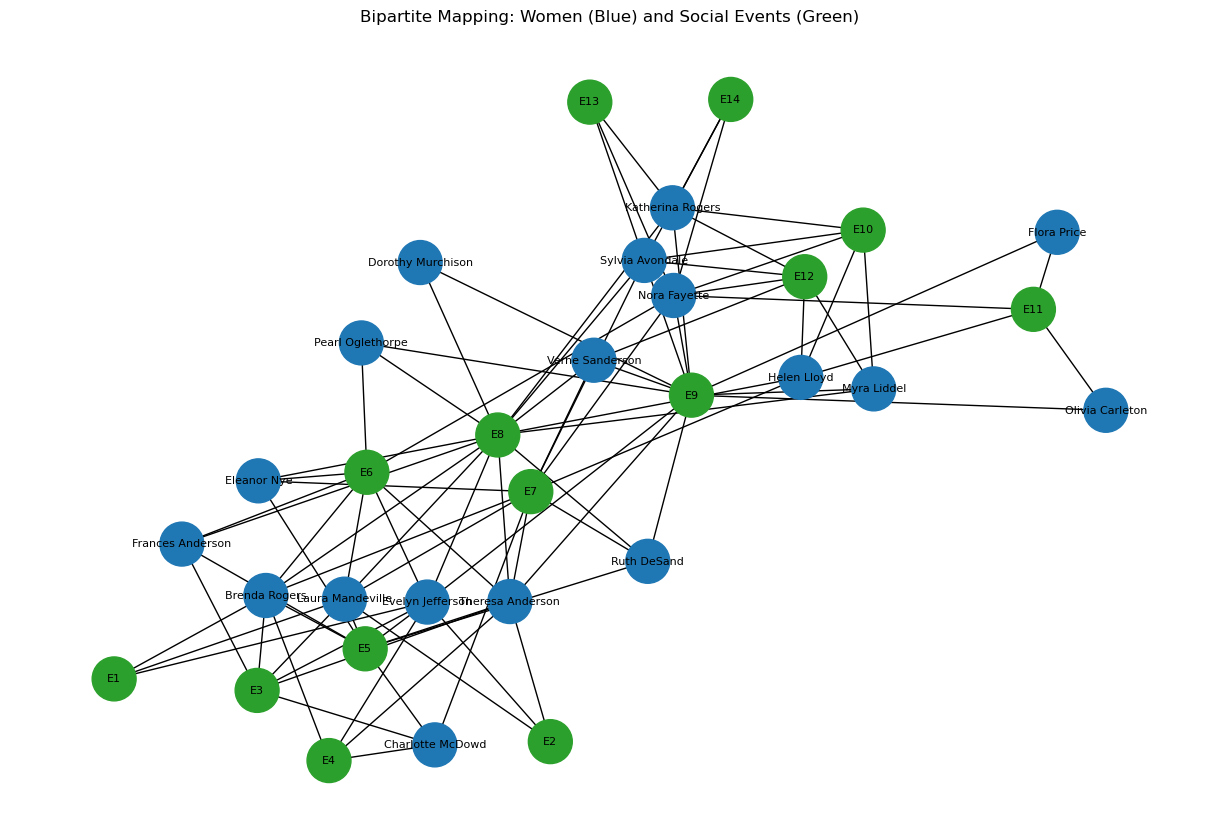

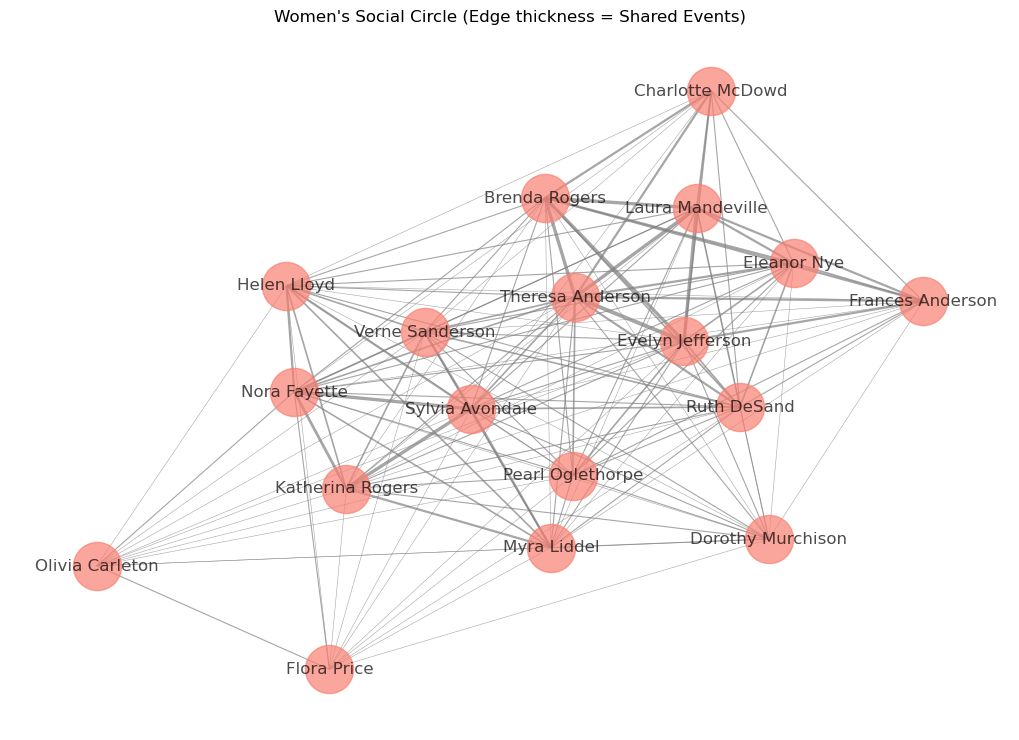

In [2]:
# Detailed network statistics
print(f"Total Nodes: {G.number_of_nodes()}")
print(f"Edges (Attendances): {G.number_of_edges()}")

# Better labels and distinction
plt.figure(figsize=(12, 8))
color_map = ['#1f77b4' if node in women else '#2ca02c' for node in G]

nx.draw(G, pos, with_labels=True, node_color=color_map, 
        node_size=1000, font_size=8, font_color="black")

plt.title("Bipartite Mapping: Women (Blue) and Social Events (Green)")
plt.show()

# Weighted relationships among women
plt.figure(figsize=(10, 7))
edge_widths = [W[u][v]['weight'] * 0.4 for u, v in W.edges()]
nx.draw(W, with_labels=True, node_color='salmon', node_size=1200, 
        width=edge_widths, edge_color='gray', alpha=0.7)
plt.title("Women's Social Circle (Edge thickness = Shared Events)")
plt.show()

## Inferences

**Relationship between the Women**

Looking at the social circles of these women, it’s clear this isn’t just one big, uniform group. Instead, there’s a very obvious core-periphery setup. Based on the "Friend Meetings" data and the thickness of the lines in my second graph, a few women (Theresa Anderson, Evelyn Jefferson, and Brenda Rogers) stand out as the real "anchors" of the community. They are the most active and have the strongest bonds, likely acting as the social bridge that holds everyone together. On the other hand, women like Olivia Carleton and Flora Price are much more on the outside, appearing in the network as part of a smaller sub-group that only occasionally joins in with the larger crowd. Overall, the group seems to be split into two main cliques that stay connected primarily through a few central "super-connectors" who prevent the whole social scene from breaking apart into two separate bubbles.


**Relationship between the Social Events**

The events also play very different roles in this social scene. Some are huge community mixers, while others are small and more exclusive. From the bipartite map, we can see that Events E6, E7, E8, and E9 are the "hubs" of the network. They sit right in the middle because they attract people from both of the main social cliques, making them the most important gatherings for keeping everyone connected. In contrast, the events out on the edges, like E1, E2, E13, and E14, seem much more private. They have lower attendance and were likely smaller club meetings or parties meant for reinforcing bonds within a specific tight-knit group. Essentially, the social calendar of this group was a mix of large "Big Tent" events that unified everyone and smaller gatherings that kept individual friendships strong.